Group: ML project 1

Section: 2

445013974	ريهام فيض الله خان

445013931	بتول حسام حلاق

445013880	افراح نور الكبير

445013908	يسرى تامر احمد

445003909	رواف تازي

In [ ]:
# imports important libraries
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib
from scipy.stats import linregress

In [ ]:
#  DATASET GENERATION (30,000 ROWS)
#  realistic puzzle‑game dataset
#  10,000 players × 3 levels each

RND = 42
np.random.seed(RND)
# Number of players and levels per player
n_players = 10000
levels_per_player = 3
rows = n_players * levels_per_player
# Repeat each player ID 3 times → for level 1,2,3
player_ids = np.repeat(np.arange(1, n_players+1), levels_per_player)
# Levels structure (1,2,3 repeated)
level_nums = np.tile(np.arange(1, levels_per_player+1), n_players)
# Base skill for each player: beta distribution gives realistic human skill spread
player_skill = np.random.beta(2, 2, size=n_players)
# Behavior type: 70% improve, 20% stable, 10% worse
behavior_group = np.random.choice(['improve','stable','worse'],
                                  size=n_players,
                                  p=[0.7,0.2,0.1])
records = []

for i in range(n_players):
    base_skill = player_skill[i]         # base ability of the player
    group = behavior_group[i]           # improvement pattern

    for lvl in range(1, levels_per_player+1):
        # Skill progression over levels
        if group == 'improve':
            # skill increases slightly with each level
            skill = base_skill + 0.05*(lvl-1) + np.random.normal(0,0.03)
        elif group == 'stable':
            # stays about the same with small noise
            skill = base_skill + np.random.normal(0,0.02)
        else:
            # gets slightly worse every level
            skill = base_skill - 0.03*(lvl-1) + np.random.normal(0,0.04)

        skill = np.clip(skill, 0.05, 0.99)
        # Time to solve puzzle:
        # higher skill = lower solve time
        time_base = 70 - 40*skill
        # more noise for low‑skill players
        time_noise = np.abs(np.random.normal(0, 8 + (1-skill)*12))
        time_to_solve = max(5, time_base + time_noise)
        # Accuracy
        accuracy = np.clip(skill + np.random.normal(0,0.06), 0.05, 0.99)
        # Hints & fails
        hints_used = int(np.random.poisson(lam=max(0.1, (1-skill)*1.8)))

        expected_attempts = 1.0 / max(0.05, accuracy)
        fails = max(0, int(np.round(np.random.poisson(lam=max(0, expected_attempts-1)))))
        attempts = int(fails + 1)
        # Score
        score = int(np.round(
            1000*(0.5*accuracy + 0.5*(1/(1+time_to_solve/100))))
            + np.random.randint(-20,20)
        )
        score = max(0, score)
        # Difficulty (baseline for each level)
        difficulty = lvl
        # Reaction time: slower for low‑skill players
        reaction_time = np.clip(np.random.normal(0.9 - 0.6*skill, 0.25), 0.2, 3.5)
        # Total session time = solve time + UI interaction
        session_time = time_to_solve + np.random.uniform(2,12)
        success = np.random.rand() < accuracy

        # Save record
        records.append({
            'player_id': i+1,
            'level': lvl,
            'time_to_solve': round(float(time_to_solve),2),
            'accuracy': round(float(accuracy),3),
            'hints_used': hints_used,
            'fails': int(fails),
            'attempts': attempts,
            'score': int(score),
            'difficulty': int(difficulty),
            'reaction_time': round(float(reaction_time),3),
            'session_time': round(float(session_time),2),
            'behavior_group': group
        })

# Convert to DataFrame
df = pd.DataFrame.from_records(records)
print("Generated dataset shape:", df.shape)
print(df.head(6))

# Save CSV
out_dir = Path('/content')
out_dir.mkdir(parents=True, exist_ok=True)
raw_path = out_dir / 'puzzle_game_30000_raw.csv'
df.to_csv(raw_path, index=False)

print("Saved raw CSV to:", raw_path)


Generated dataset shape: (30000, 12)
   player_id  level  time_to_solve  accuracy  hints_used  fails  attempts  \
0          1      1          54.63     0.669           0      0         1   
1          1      2          47.19     0.725           0      0         1   
2          1      3          51.10     0.688           0      0         1   
3          2      1          52.47     0.652           1      2         3   
4          2      2          61.88     0.510           1      0         1   
5          2      3          53.37     0.607           1      0         1   

   score  difficulty  reaction_time  session_time behavior_group  
0    640           1          0.228         59.13        improve  
1    685           2          0.254         56.96        improve  
2    684           3          0.518         56.79        improve  
3    650           1          0.488         63.85        improve  
4    552           2          0.306         72.92        improve  
5    642           3 

In [ ]:
#  Per‑Player Aggregation
#  extract one row per player, summarizing performance

# Group data by player_id and compute summary statistics
player_agg = df.groupby('player_id').agg(
    avg_time=('time_to_solve', 'mean'),      # average puzzle solve time
    std_time=('time_to_solve', 'std'),       # variability of solve time
    avg_accuracy=('accuracy', 'mean'),       # average accuracy across levels
    std_accuracy=('accuracy', 'std'),        # how stable accuracy is
    avg_fails=('fails', 'mean'),             # average number of failed attempts
    avg_hints=('hints_used', 'mean'),        # average hints used
    avg_score=('score', 'mean'),             # average player score
    attempts_mean=('attempts', 'mean')       # average number of attempts
).fillna(0)  # replace missing values

#  Compute learning_slope:
#  measure how much a player's score improves or drops
def score_slope(pid):
    # Extract only rows for this player, ordered by level
    rows_p = df[df['player_id'] == pid].sort_values('level')

    # Apply linear regression on: X = level, Y = score
    return linregress(rows_p['level'], rows_p['score']).slope

# Apply slope function to each player
player_agg['learning_slope'] = [score_slope(pid) for pid in player_agg.index]

#  Save aggregated dataset to CSV
agg_path = out_dir / 'player_aggregates.csv'
player_agg.to_csv(agg_path)
print("Player aggregates saved to:", agg_path)
print(player_agg.head(6))


Player aggregates saved to: /content/player_aggregates.csv
            avg_time  std_time  avg_accuracy  std_accuracy  avg_fails  \
player_id                                                               
1          50.973333  3.721617      0.694000      0.028478   0.000000   
2          55.906667  5.192594      0.589667      0.072570   0.666667   
3          49.710000  4.963235      0.695000      0.055669   0.666667   
4          64.846667  5.497284      0.337667      0.046918   2.333333   
5          36.493333  2.181750      0.949000      0.071014   0.000000   
6          64.900000  8.743072      0.444667      0.079727   1.333333   

           avg_hints   avg_score  attempts_mean  learning_slope  
player_id                                                        
1           0.000000  669.666667       1.000000            22.0  
2           1.000000  614.666667       1.666667            -4.0  
3           0.000000  680.666667       1.666667            42.0  
4           0.333333  484.

Clusters assigned. Counts per rank:
cluster_rank
1     582
2    2319
3    2304
4    2079
5    2716
Name: count, dtype: int64


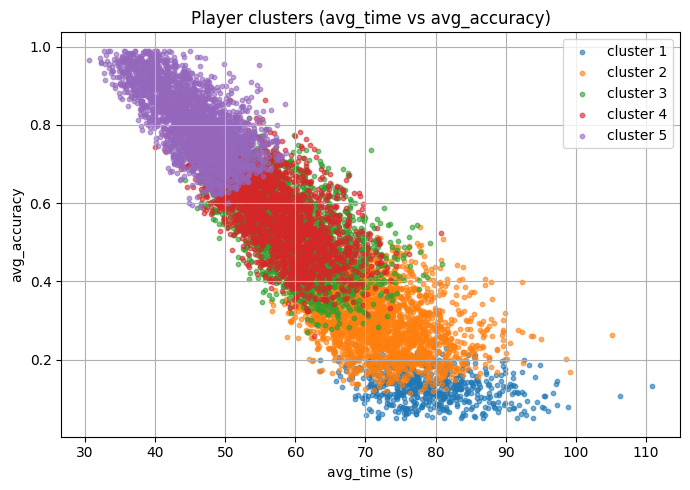

In [ ]:
# KMeans Clustering (k = 5)
# clustering and assigning difficulty rank to players based on their aggregated behavior

# Features used to cluster players based on overall performance
features_for_clustering = ['avg_time','avg_accuracy','avg_score','avg_fails','learning_slope']
X = player_agg[features_for_clustering].copy()
# Scale features (KMeans is sensitive to different scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply KMeans clustering (k = 5)
k = 5
kmeans = KMeans(n_clusters=k, random_state=RND, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
player_agg['cluster'] = clusters
# Convert cluster labels (0–4) into ranked difficulty levels (1–5)
# Ranking is based on average accuracy: lower accuracy → lower skill
cluster_order = player_agg.groupby('cluster')['avg_accuracy'].mean().sort_values().index.tolist()
cluster_rank = {c:i+1 for i,c in enumerate(cluster_order)} # rank: weakest=1 → strongest=5
player_agg['cluster_rank'] = player_agg['cluster'].map(cluster_rank)

# Merge cluster information back into the main dataset (df)
# Each level row now knows its player's cluster + rank
df = df.drop(columns=['cluster', 'cluster_rank'], errors='ignore')
df = df.merge(player_agg[['cluster','cluster_rank']], left_on='player_id', right_index=True, how='left')

# Save models (useful for later prediction)
joblib.dump(kmeans, out_dir / 'kmeans_model.joblib')
joblib.dump(scaler, out_dir / 'scaler.joblib')

print("Clusters assigned. Counts per rank:")
print(player_agg['cluster_rank'].value_counts().sort_index())

# Visualization: Scatter plot of clusters
plt.figure(figsize=(7,5))
for r in sorted(player_agg['cluster_rank'].unique()):
    subset = player_agg[player_agg['cluster_rank'] == r]
    plt.scatter(subset['avg_time'], subset['avg_accuracy'], label=f'cluster {r}', alpha=0.6, s=10)
plt.xlabel('avg_time (s)')
plt.ylabel('avg_accuracy')
plt.title('Player clusters (avg_time vs avg_accuracy)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(out_dir / 'clusters_scatter.png')
plt.show()

In [ ]:
#  Feature Engineering + Creating Target Variable

# Sort dataset so each player’s levels appear in correct order
df = df.sort_values(['player_id','level']).reset_index(drop=True)
# Merge aggregated per‑player stats into every level row
df = df.merge(
    player_agg[['avg_time','std_time','avg_accuracy','learning_slope','cluster_rank']],
    left_on='player_id',
    right_index=True,
    how='left'
)
# New target: generate_difficulty
# Creates a realistic, non‑trivial difficulty label (1/2/3)
# Avoids data leakage → avoids achieving unrealistic 100% accuracy
def generate_difficulty(row):
    # Weighted components reflecting player skill
    score_component = row["avg_score"] / 400        # normalized
    accuracy_component = row["avg_accuracy"] * 1.2  # stronger influence
    time_component = 1 - (row["avg_time"] / 100)    # lower time → higher skill

    # Combined skill indicator
    raw_value = accuracy_component + score_component + time_component
    # Convert continuous score → difficulty level
    if raw_value > 1.8:
        return 3  # hardest level
    elif raw_value < 1.2:
        return 1  # easiest level
    else:
        return 2

# Apply target to the per‑player aggregated dataset
player_agg["optimal_difficulty"] = player_agg.apply(generate_difficulty, axis=1)

# Merge the difficulty back into the main df
# Each level row now inherits the player's optimal difficulty
df = df.merge(
    player_agg[['optimal_difficulty']],
    left_on='player_id',
    right_index=True,
    how='left'
)
# Save engineered dataset for model training
eng_path = out_dir / 'puzzle_game_engineered.csv'
df.to_csv(eng_path, index=False)

print("Engineered dataset saved to:", eng_path)
print(df[['player_id','level','accuracy','time_to_solve','optimal_difficulty']].head(8))


Engineered dataset saved to: /content/puzzle_game_engineered.csv
   player_id  level  accuracy  time_to_solve  optimal_difficulty
0          1      1     0.669          54.63                   3
1          1      2     0.725          47.19                   3
2          1      3     0.688          51.10                   3
3          2      1     0.652          52.47                   3
4          2      2     0.510          61.88                   3
5          2      3     0.607          53.37                   3
6          3      1     0.637          54.50                   3
7          3      2     0.700          50.04                   3


Test accuracy: 0.9853
              precision    recall  f1-score   support

           1      0.947     0.947     0.947        75
           2      0.959     0.951     0.955       489
           3      0.992     0.993     0.993      2436

    accuracy                          0.985      3000
   macro avg      0.966     0.964     0.965      3000
weighted avg      0.985     0.985     0.985      3000



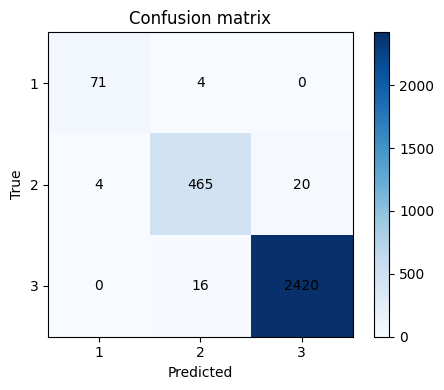

Top features:
 avg_accuracy      0.398040
accuracy          0.181364
avg_time          0.161042
cluster_rank_x    0.109598
attempts          0.034858
time_to_solve     0.030879
fails             0.029042
session_time      0.016904
dtype: float64


In [ ]:
# Train RandomForest Classifier to Predict Difficulty

# Recalculate cluster ranks inside df (ensures consistency)
cluster_perf = player_agg.groupby('cluster')['avg_accuracy'].mean().sort_values()
cluster_rank_map = {cluster: rank for rank, cluster in enumerate(cluster_perf.index)}
df['cluster_rank'] = df['cluster'].map(cluster_rank_map)

# Features used for the ML classifier
clf_features = [
    'time_to_solve','accuracy','hints_used','fails','attempts',
    'reaction_time','session_time',
    'avg_time','std_time','avg_accuracy','learning_slope',
    'cluster_rank_x'
]
X = df[clf_features]
y = df['optimal_difficulty']

# Train/test split by player_id to avoid data leakage
player_ids_unique = df['player_id'].unique()
train_pids, test_pids = train_test_split(player_ids_unique, test_size=0.10, random_state=RND)
train_idx = df['player_id'].isin(train_pids)
test_idx = df['player_id'].isin(test_pids)
X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

# Train RandomForest classifier
rf = RandomForestClassifier(
    n_estimators=200,     # number of trees
    random_state=RND,
    n_jobs=-1             # use all CPU cores
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
# Save model
joblib.dump(rf, out_dir / 'rf_difficulty_model.joblib')

# Evaluation
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(acc,4))
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0,1,2],[1,2,3])
plt.yticks([0,1,2],[1,2,3])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig(out_dir / 'confusion_matrix.png')
plt.show()

# Feature importances (which features the model relies on most)
importances = pd.Series(rf.feature_importances_, index=clf_features).sort_values(ascending=False)
print("Top features:\n", importances.head(8))
importances.to_csv(out_dir / 'feature_importances.csv')

In [ ]:
# Apply Model + Simulate Before vs After Performance
# compare player performance before and after applying ML‑based dynamic difficulty adjustment (DDA).

# Predict difficulty using the trained RandomForest model
df['predicted_difficulty'] = rf.predict(df[clf_features])
# Keep the original game difficulty (baseline)
df['difficulty_before'] = df['difficulty']
# The improved difficulty suggested by the model
df['difficulty_after'] = df['predicted_difficulty']

# simulate the effect of dynamic difficulty adjustment.
def simulate_effect(row):
    base = row['accuracy']  # original success chance

    # Apply difficulty change rules
    if row['difficulty_after'] < row['difficulty_before']:
        new_succ = min(0.99, base + 0.25) # easier → improves
    elif row['difficulty_after'] > row['difficulty_before']:
        new_succ = max(0.01, base - 0.02) # harder → declines
    else:
        new_succ = base # unchanged

    # Expected attempts after modification
    expected_attempts = 1.0 / max(0.05, new_succ)
    # Expected time: scaled by expected attempts
    expected_time = row['time_to_solve'] * (expected_attempts / max(1, row['attempts']))

    return pd.Series({
        'sim_success': new_succ,
        'sim_expected_attempts': expected_attempts,
        'sim_expected_time': expected_time
    })
# Apply simulation to every row
sim = df.apply(simulate_effect, axis=1)

# Assign columns directly instead of using pd.concat to prevent duplicate columns upon re-run
df['sim_success'] = sim['sim_success']
df['sim_expected_attempts'] = sim['sim_expected_attempts']
df['sim_expected_time'] = sim['sim_expected_time']

# Performance Summary (Before → After)
summary = {
    'before_success_rate': df['accuracy'].mean(),
    'after_success_rate': df['sim_success'].mean(),

    'before_avg_attempts': df['attempts'].mean(),
    'after_avg_attempts': df['sim_expected_attempts'].mean(),

    'before_avg_time': df['time_to_solve'].mean(),
    'after_avg_time': df['sim_expected_time'].mean()
}
# Save summary as JSON
import json
with open(out_dir / 'before_after_summary.json','w') as f:
    json.dump(summary, f, indent=2)
print("Summary:", summary)

# Save final dataset with predictions and simulation effects
final_path = out_dir / 'puzzle_game_final_with_predictions.csv'
df.to_csv(final_path, index=False)
print("Final CSV saved to:", final_path)

Summary: {'before_success_rate': np.float64(0.5364914666666666), 'after_success_rate': np.float64(0.5425518), 'before_avg_attempts': np.float64(2.6961), 'after_avg_attempts': np.float64(2.4814359269182202), 'before_avg_time': np.float64(59.310817666666665), 'after_avg_time': np.float64(70.24320195797732)}
Final CSV saved to: /content/puzzle_game_final_with_predictions.csv


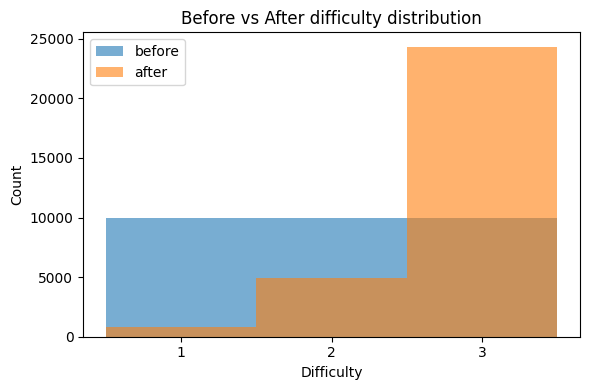

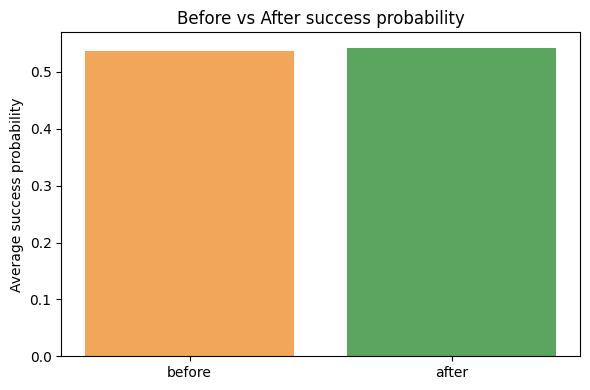

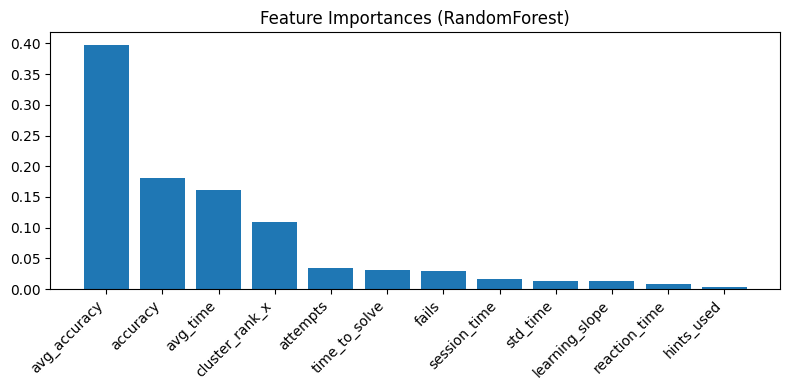

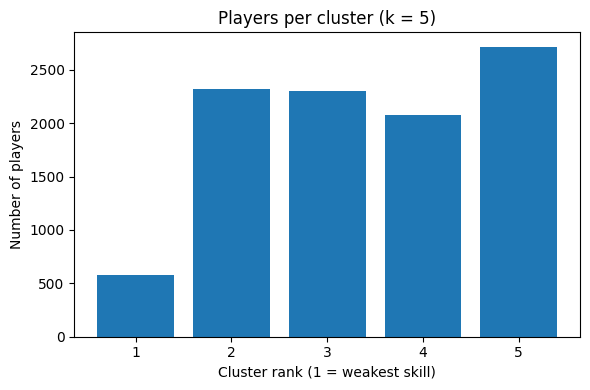

Plots saved to /content


In [ ]:
# Visualizations for Before/After + Clusters + Features

# 1) Histogram: Before vs After difficulty distribution
plt.figure(figsize=(6,4))
# Histogram of original difficulty
plt.hist(df['difficulty_before'],
         bins=[0.5,1.5,2.5,3.5],
         alpha=0.6,
         label='before')
# Histogram of predicted (after) difficulty
plt.hist(df['difficulty_after'],
         bins=[0.5,1.5,2.5,3.5],
         alpha=0.6,
         label='after')

plt.xticks([1,2,3])
plt.xlabel('Difficulty')
plt.ylabel('Count')
plt.title('Before vs After difficulty distribution')
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / 'before_after_difficulty_hist.png')
plt.show()

# 2) Bar chart: Before vs After success probability
plt.figure(figsize=(6,4))
plt.bar(['before','after'],
        [summary['before_success_rate'], summary['after_success_rate']],
        color=['#f2a65a','#5aa65f'])

plt.ylabel('Average success probability')
plt.title('Before vs After success probability')
plt.tight_layout()
plt.savefig(out_dir / 'before_after_success_bar.png')
plt.show()

# 3) Feature Importance bar chart (from RandomForest)
try:
    # Read the saved importances as a Series
    fi = pd.read_csv(out_dir / 'feature_importances.csv', index_col=0).squeeze()

    plt.figure(figsize=(8,4))
    plt.bar(fi.index, fi.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Feature Importances (RandomForest)')
    plt.tight_layout()
    plt.savefig(out_dir / 'feature_importances.png')
    plt.show()

except Exception as e:
    print("Could not plot importances from file:", e)

# 4) Players per cluster (rank 1 → 5)
plt.figure(figsize=(6,4))
counts = player_agg['cluster_rank'].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.xlabel('Cluster rank (1 = weakest skill)')
plt.ylabel('Number of players')
plt.title('Players per cluster (k = 5)')
plt.tight_layout()
plt.savefig(out_dir / 'players_per_cluster.png')
plt.show()

print("Plots saved to", out_dir)